In [1]:
from sqlalchemy import create_engine
from snowflake.sqlalchemy import URL
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

c:\Users\knguy139\Documents\Projects\.venv\Lib\site-packages\snowflake\connector\vendored\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(


In [3]:
# Connect to Snowflake
engine = create_engine(URL(
    account = "UHG-UHGDWAAS",
    user = "KHANG.NGUYEN@UHC.COM",
    authenticator = "externalbrowser",
    role = "AZU_SDRP_VING_PRD_DEVELOPER_ROLE",
    warehouse = "VING_PRD_MNR_HCE_DATAINFRA_WH",
    database = "VING_PRD_TREND_DB",
    schema = "TMP_1M"
))

In [71]:
# hospital_group aggregation — MNR FFS, 2025 only (202501-202512)
df = pd.read_sql("""
    select
        d.collection as hospital_group
        , a.fin_market
        , count(*) as case_count_2025
        , sum(a.initialfulladr_cases) as initial_adr_cnt_2025
        , sum(a.persistentfulladr_cases) as persistent_adr_cnt
        , sum(a.p2p_full_ovtn) as p2p_ovrtn_cnt
        , sum(a.appeal_ovrtn_ind) as appeal_ovrtn_cnt
        , sum(a.mcr_ovtrn_ind) as mcr_ovrtn_cnt
        , sum(a.icm_md_reviewed_ind) as md_reviewed_cnt
    from tmp_1m.ec_avtar_25_26_3_od as a
    left join tmp_1y.tin_collection as d
        on substr(a.fa_prov_id, 2, 9) = d.tin
    where fin_brand in ('M&R', 'C&S')
        and (
            (ip_type in ('Medical', 'Surgical', 'Transplant')
             and to_varchar(admit_dt_act, 'MM/dd/yyyy') is not null)
            or ip_type in ('LTAC', 'SNF', 'AIR')
        )
        and fin_brand = 'M&R'
        and loc_flag = 1
        and (
            (global_cap = 'NA' and sgr_source_name = 'COSMOS'
             and fin_product_level_3 != 'INSTITUTIONAL' and tfm_include_flag = 1)
            or (sgr_source_name = 'NICE' and nce_tadm_dec_risk_type in ('FFS', 'PHYSICIAN'))
        )
        and hce_admit_month between '202501' and '202512'
    group by 1,2
    having count(*) >= 30
""", engine)

print(f"Core (2025): {df.shape}")

 pip install snowflake-connector-python[secure-local-storage]


Initiating login request with your identity provider. Press CTRL+C to abort and try again...
Going to open: https://login.microsoftonline.com/db05faca-c82a-4b9d-b9c5-0f64b6755421/saml2?SAMLRequest=lZLNbuIwFEZfJfKsEydpkoIFVLS0Gkb9oQW6YDNybAdcHJv6OqR9%2BzGhSJ1FK3URKXLO5xz7u4OLt1oFe2FBGj1ESRSjQGhmuNTrIVoubsIeCsBRzakyWgzRuwB0MRoArdWOjBu30U%2FitRHgAr%2BRBtJ9GKLGamIoSCCa1gKIY2Q%2BvrslaRSTnTXOMKPQp8j3CQogrPOGpwgH6fU2zu0Ixm3bRu1ZZOwap3Ec47iPPXVAfp34N3%2BmL%2FgEx9mB94THZx9ul1Ifr%2BA7rfIIAfm9WMzC2cN8gYLxSfXKaGhqYefC7iUTy6fbowB4g2azDv3DW0rh74ZGoE1bKboVzNS7xvk9I%2F%2BGK8GxMmvpjz2dDNFuK%2FlqPUkf56%2BTO%2BhvC%2FpC6fX%2BQXFz%2FXLev8zuV9vHZflnU2S1yzKGgudTr%2Bmh1ylAI6b60KbzS3FahHEepsUiOSNpQZIi6uXFCgUT36bU1HXJk3LnEdWSWQOmckYrqUVnycs4ryijIeulNMzKPg%2FLPsvDuCqysjjP8yxN8KHjFB3nhnQidvSz2xjgz9mPAbz3nUwnM6Mkew9ujK2p%2B7qyJEq6FcnDqkOJqKlUY86tAPDVKWXaKyuo83PubCMQHh3%2F%2Bv%2Bkj%2F4B&RelayState=ver%3A3-hint%3A260092055407922-ETMsDgAAAZ5kdvAYABRBRVMvQ0JDL1BLQ1M1UGFkZGluZwEAABAAEDShu%2FvcXb304iySLpAieGcAAACQw0crS9

In [72]:
# member_appeal — 202601+ only (separate time range)
df_ma = pd.read_sql("""
    select
        d.collection as hospital_group
        , a.fin_market
        , count(*) as case_count_2026
        , sum(a.initialfulladr_cases) as initial_adr_cnt_2026
        , sum(a.member_appeal_ind) as member_appeal_cnt
        , sum(a.member_appeal_ovtn_ind) as member_appeal_ovtn_cnt
    from tmp_1m.ec_avtar_25_26_3_od as a
    left join tmp_1y.tin_collection as d
        on substr(a.fa_prov_id, 2, 9) = d.tin
    where fin_brand in ('M&R', 'C&S')
        and (
            (ip_type in ('Medical', 'Surgical', 'Transplant')
             and to_varchar(admit_dt_act, 'MM/dd/yyyy') is not null)
            or ip_type in ('LTAC', 'SNF', 'AIR')
        )
        and fin_brand = 'M&R'
        and loc_flag = 1
        and (
            (global_cap = 'NA' and sgr_source_name = 'COSMOS'
             and fin_product_level_3 != 'INSTITUTIONAL' and tfm_include_flag = 1)
            or (sgr_source_name = 'NICE' and nce_tadm_dec_risk_type in ('FFS', 'PHYSICIAN'))
        )
        and hce_admit_month >= '202601'
    group by 1,2
    having sum(a.initialfulladr_cases) >= 10
""", engine)

engine.dispose()
print(f"Member appeal (202601+): {df_ma.shape}")

Member appeal (202601+): (965, 6)


In [73]:
# merge member_appeal onto core
df = df.merge(df_ma, on = ["hospital_group","fin_market"], how = "left")
print(f"After merge: {df.shape}")

After merge: (1884, 13)


In [75]:
# compute rates
df = (
    df
    .assign(
        initial_adr_rate_2025 = lambda x: x.initial_adr_cnt_2025 / x.case_count_2025,
        persistent_adr_rate = lambda x: x.persistent_adr_cnt / x.case_count_2025,
        p2p_overturn_rate = lambda x: x.p2p_ovrtn_cnt / x.initial_adr_cnt_2025.replace(0, np.nan),
        appeal_overturn_rate = lambda x: x.appeal_ovrtn_cnt / x.initial_adr_cnt_2025.replace(0, np.nan),
        mcr_overturn_rate = lambda x: x.mcr_ovrtn_cnt / x.initial_adr_cnt_2025.replace(0, np.nan),
        md_review_rate = lambda x: x.md_reviewed_cnt / x.case_count_2025,
        member_appeal_rate = lambda x: x.member_appeal_cnt / x.initial_adr_cnt_2026.replace(0, np.nan),
        initial_adr_rate_2026 = lambda x: x.initial_adr_cnt_2026 / x.case_count_2026,
    )
    .dropna(subset = ["p2p_overturn_rate", "member_appeal_rate"])
)

rate_cols = [
    "initial_adr_rate_2025", "persistent_adr_rate", "p2p_overturn_rate",
    "appeal_overturn_rate", "mcr_overturn_rate", "md_review_rate", "member_appeal_rate",
    "initial_adr_rate_2026"
]
count_cols = [
    "case_count_2025", "initial_adr_cnt_2025", "persistent_adr_cnt", "p2p_ovrtn_cnt",
    "appeal_ovrtn_cnt", "mcr_ovrtn_cnt", "md_reviewed_cnt",
    "case_count_2026", "member_appeal_cnt", "initial_adr_cnt_2026"
]
fill_cols = rate_cols + count_cols

df[fill_cols] = df[fill_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"Shape: {df.shape[0]}")

Shape: 948


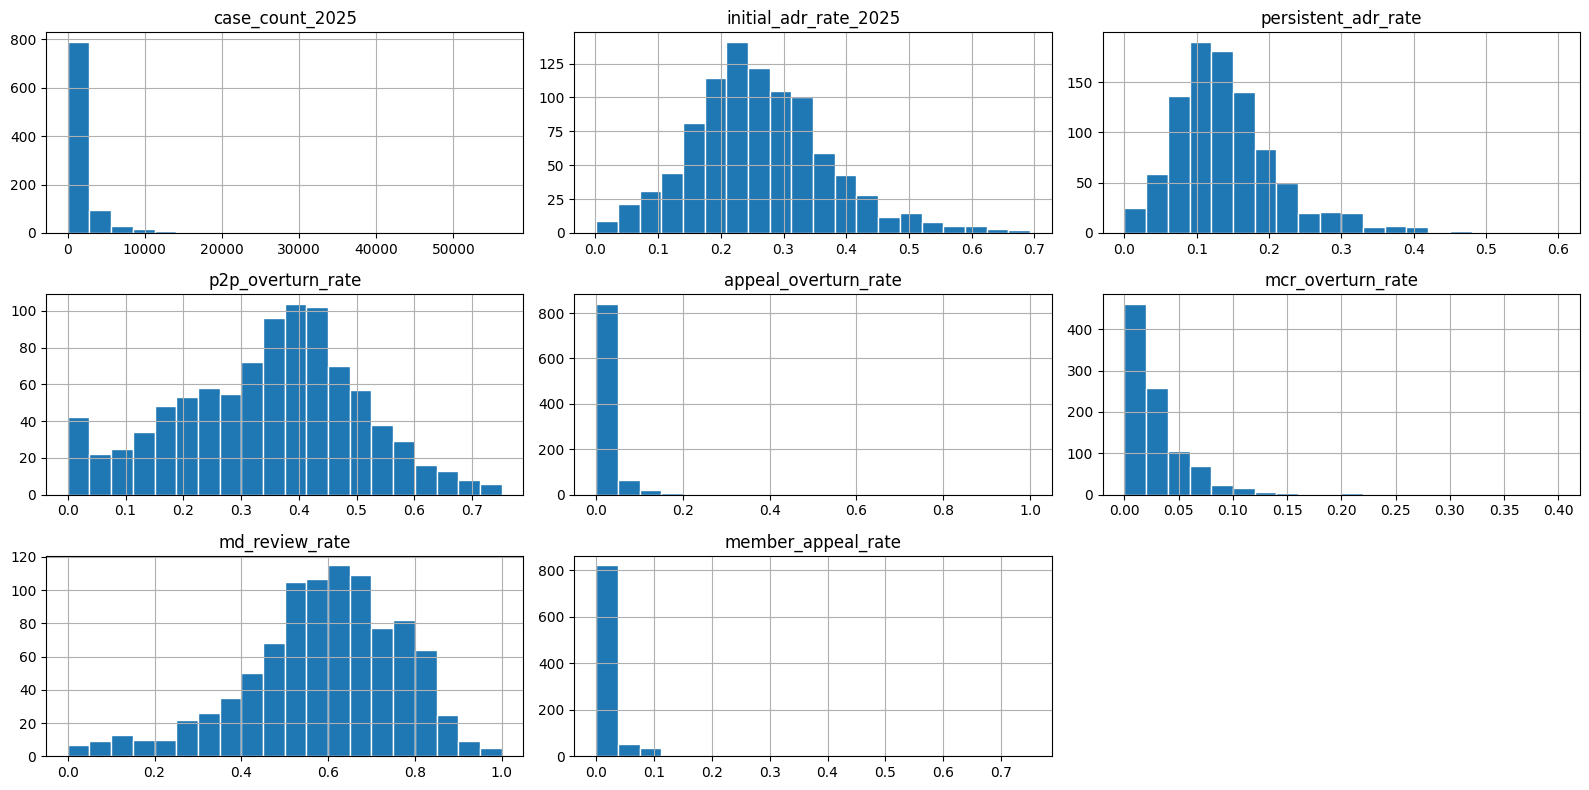

In [85]:
# EDA
kpi = ["case_count_2025", "initial_adr_rate_2025", "persistent_adr_rate", "p2p_overturn_rate",
    "appeal_overturn_rate", "mcr_overturn_rate", "md_review_rate",
    "member_appeal_rate"]

df[kpi].describe().round(4)

df[kpi].hist(bins = 20, figsize = (16, 8), edgecolor = "white")

plt.tight_layout()
plt.show()

In [86]:
# Standardize + Fit models
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[kpi])

# Assuming 5% anomalous, 200 trees; 42 is standard 
iso = IsolationForest(contamination = 0.05, n_estimators = 300, random_state = 42)
iso.fit(X_scaled)

df = (
    df
    .assign(
        anomaly_score = iso.decision_function(X_scaled),
        anomaly_flag = iso.predict(X_scaled) == -1
    )
)

(
    df
    [["hospital_group", "fin_market", *kpi, "anomaly_score", "anomaly_flag"]]
    .sort_values(["case_count_2025", "anomaly_score"], ascending = [False, True])
)


,hospital_group,fin_market,case_count_2025,initial_adr_rate_2025,persistent_adr_rate,p2p_overturn_rate,appeal_overturn_rate,mcr_overturn_rate,md_review_rate,member_appeal_rate,anomaly_score,anomaly_flag
627,None,LA,56255,0.048636,0.038699,0.002193,0.042398,0.061769,0.001618,0.019351,-0.143715,True
1502,HCA INC,FL,39002,0.379545,0.188247,0.445450,0.013443,0.021009,0.618353,0.010432,-0.018848,True
1768,None,MA,25834,0.291012,0.153596,0.382815,0.024076,0.021681,0.516180,0.010417,0.019289,False
747,HCA INC,TX,25784,0.251629,0.120966,0.427250,0.031289,0.037300,0.518771,0.032838,-0.000201,True
1179,None,CT,23594,0.198567,0.128846,0.223906,0.032657,0.019210,0.428075,0.013033,0.005324,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1469,NEVADA CITY HOSPITAL,MO,31,0.612903,0.290323,0.473684,0.000000,0.052632,0.935484,0.235294,-0.045914,True
1334,LORETTO HOSPITAL,IL,31,0.677419,0.548387,0.142857,0.000000,0.000000,0.806452,0.000000,-0.035127,True
1571,Sierra View District Hospital,CA-N,31,0.354839,0.161290,0.181818,0.000000,0.090909,0.870968,0.000000,0.085981,False
1663,KUAKINI MEDICAL CENTER,HI,31,0.161290,0.096774,0.000000,0.000000,0.000000,0.677419,0.000000,0.106942,False


In [84]:
flagged = (
    df
    .query("anomaly_flag == 1")
    .sort_values(["anomaly_score", "case_count_2025"], ascending = [True, False])
    [["hospital_group", "fin_market", "case_count_2025", "reason", "z_score", *kpi, "anomaly_score"]]
    .round(4)
)
print(f"Flagged hospitals: {len(flagged)}")
flagged

Flagged hospitals: 48


,hospital_group,fin_market,case_count_2025,reason,z_score,initial_adr_rate_2025,persistent_adr_rate,p2p_overturn_rate,appeal_overturn_rate,mcr_overturn_rate,md_review_rate,member_appeal_rate,anomaly_score
1223,ASH,AR,194,mcr_overturn_rate (high),11.5711,0.0515,0.0206,0.0000,0.0000,0.4000,0.0670,0.1818,-0.1496
163,IHC,UT,9148,appeal_overturn_rate (high),13.1478,0.0011,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,-0.1495
751,MOUNT SINAI MEDICAL CENTER OF FLORIDA,FL,5512,appeal_overturn_rate (high),13.1478,0.0129,0.0000,0.0000,1.0000,0.0000,0.0005,0.0000,-0.1482
1817,Nassau Health,NY,128,member_appeal_rate (high),5.4527,0.5859,0.3047,0.0667,0.0000,0.1467,0.7031,0.4400,-0.1321
1001,ETHICUS HOSPITAL DFW,TX,216,appeal_overturn_rate (high),11.3523,0.0694,0.0093,0.0000,0.8667,0.0000,0.0139,0.0000,-0.1251
1006,WESTCHESTER GENERAL HOSPITAL,FL,114,persistent_adr_rate (high),4.4257,0.6930,0.4737,0.0633,0.0000,0.1139,0.6404,0.1500,-0.1246
1673,OKLAHOMA SPINE HOSPITAL,OK,1286,appeal_overturn_rate (high),10.2204,0.0537,0.0054,0.0000,0.7826,0.0000,0.0264,0.0000,-0.1123
494,HOSPITAL AUTHORITY OF WAYNE COUNTY GA,GA,147,member_appeal_rate (high),5.8536,0.3878,0.3061,0.0000,0.0000,0.0877,0.8571,0.4706,-0.0893
1100,None,NE,60,persistent_adr_rate (high),6.1074,0.6000,0.6000,0.0000,0.0000,0.0000,0.1500,0.0000,-0.0886
1469,NEVADA CITY HOSPITAL,MO,31,initial_adr_rate_2025 (high),3.1877,0.6129,0.2903,0.4737,0.0000,0.0526,0.9355,0.2353,-0.0839


In [11]:
# all z-scores for flagged entities — see full profile
(
    df
    .query("anomaly_flag == 1")
    .sort_values("anomaly_score")
    [["hospital_group", *kpi, *z_cols]]
    .round(2)
)

,hospital_group,initial_adr_rate,persistent_adr_rate,p2p_overturn_rate,appeal_overturn_rate,mcr_overturn_rate,md_review_rate,member_appeal_rate,z_initial_adr_rate,z_persistent_adr_rate,z_p2p_overturn_rate,z_appeal_overturn_rate,z_mcr_overturn_rate,z_md_review_rate,z_member_appeal_rate
1239,ASH,0.05,0.02,0.00,0.00,0.40,0.07,0.18,-1.89,-1.60,-2.04,-0.32,11.54,-2.87,2.10
1265,MOUNT SINAI MEDICAL CENTER OF FLORIDA,0.01,0.00,0.00,1.00,0.00,0.00,0.00,-2.23,-1.87,-2.04,12.55,-0.86,-3.23,-0.32
1259,Nassau Health,0.58,0.30,0.06,0.00,0.14,0.70,0.41,2.85,2.08,-1.65,-0.32,3.51,0.55,5.11
218,ETHICUS HOSPITAL DFW,0.07,0.01,0.00,0.87,0.00,0.01,0.00,-1.74,-1.75,-2.04,10.84,-0.86,-3.16,-0.32
1044,WESTCHESTER GENERAL HOSPITAL,0.69,0.47,0.06,0.00,0.11,0.64,0.15,3.88,4.29,-1.65,-0.32,2.67,0.24,1.73
573,OKLAHOMA SPINE HOSPITAL,0.05,0.01,0.00,0.78,0.00,0.03,0.00,-1.86,-1.79,-2.04,9.75,-0.86,-3.09,-0.32
387,HOSPITAL AUTHORITY OF WAYNE COUNTY GA,0.38,0.30,0.00,0.00,0.09,0.85,0.53,1.09,2.06,-2.04,-0.32,1.86,1.35,6.79
904,BAPTIST WOMENS HEALTH CENTER,0.12,0.03,0.06,0.68,0.02,0.02,0.00,-1.28,-1.52,-1.64,8.40,-0.36,-3.12,-0.32
1149,IHC,0.00,0.00,0.04,0.40,0.00,0.00,0.00,-2.32,-1.85,-1.79,4.83,-0.86,-3.21,-0.32
653,ELLA E M BROWN CHARITABLE CIRC,0.31,0.16,0.25,0.11,0.06,0.72,0.62,0.42,0.25,-0.51,1.11,0.86,0.66,8.01


In [ ]:
# export
df.to_csv(r"C:\Users\knguy139\Documents\Projects\Data\Output\loc_if_hospital_group.csv", index = False)
flagged.to_csv(r"C:\Users\knguy139\Documents\Projects\Data\Output\loc_if_hospital_group_flagged.csv", index = False)
print("Exported.")   
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

Exported.


In [117]:
# =============================================================================
# Denominator-aware Isolation Forest + MAD-based z_score driver identification
# - IF detects anomalies (distribution-free)
# - MAD z-scores explain WHY (robust to skew, no normality assumption)
# - Empirical Bayes shrinkage stabilizes rates for low-volume entities
# =============================================================================

from scipy.stats import median_abs_deviation

df_iso = df.copy()

# --- Data prep: clean infinities and nulls in count columns ---
base_count_cols = [
    "case_count_2025", "initial_adr_cnt_2025", "persistent_adr_cnt", "p2p_ovrtn_cnt",
    "appeal_ovrtn_cnt", "mcr_ovrtn_cnt", "md_reviewed_cnt",
    "case_count_2026", "member_appeal_cnt", "initial_adr_cnt_2026"
]

df_iso[base_count_cols] = (
    df_iso[base_count_cols]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

# --- Eligibility filter: minimum volume thresholds ---
# Ensures flagged entities have enough data for rates to be meaningful
df_iso = (
    df_iso
    .query("case_count_2025 >= 30 and initial_adr_cnt_2025 >= 10 and initial_adr_cnt_2026 >= 10")
    .copy()
)

# --- Empirical Bayes shrinkage (credibility weighting) ---
# adjusted_rate = (observed_num + k * global_rate) / (observed_den + k)
# k=50 pulls small-sample rates toward the population mean, reducing noise
rate_map = {
    "initial_adr_rate_2025": ("initial_adr_cnt_2025", "case_count_2025"),
    "persistent_adr_rate": ("persistent_adr_cnt", "case_count_2025"),
    "p2p_overturn_rate": ("p2p_ovrtn_cnt", "initial_adr_cnt_2025"),
    "appeal_overturn_rate": ("appeal_ovrtn_cnt", "initial_adr_cnt_2025"),
    "mcr_overturn_rate": ("mcr_ovrtn_cnt", "initial_adr_cnt_2025"),
    "md_review_rate": ("md_reviewed_cnt", "case_count_2025"),
    "member_appeal_rate": ("member_appeal_cnt", "initial_adr_cnt_2026"),
    "initial_adr_rate_2026": ("initial_adr_cnt_2026", "case_count_2026")
}

global_rates = {}

for rate_col, (num_col, den_col) in rate_map.items():
    den_sum = df_iso[den_col].sum()
    global_rates[rate_col] = df_iso[num_col].sum() / den_sum if den_sum != 0 else 0

def adjusted_rate(num, den, global_rate, k = 50):
    return (num + k * global_rate) / (den + k)

for rate_col, (num_col, den_col) in rate_map.items():
    df_iso[rate_col] = adjusted_rate(
        df_iso[num_col],
        df_iso[den_col],
        global_rates[rate_col],
        k = 50
    )

# --- Log-volume features ---
# Gives IF explicit volume signal so it can distinguish
# "outlier due to genuine behavior" vs "outlier due to tiny sample"
df_iso = (
    df_iso
    .assign(
        log_case_count_2025 = lambda x: np.log1p(x.case_count_2025),
        log_initial_adr_cnt_2025 = lambda x: np.log1p(x.initial_adr_cnt_2025),
        log_initial_adr_cnt_2026 = lambda x: np.log1p(x.initial_adr_cnt_2026)
    )
)

iso_kpi = [
    "log_case_count_2025",
    "log_initial_adr_cnt_2025",
    "log_initial_adr_cnt_2026",
    "initial_adr_rate_2025",
    "persistent_adr_rate",
    "p2p_overturn_rate",
    "appeal_overturn_rate",
    "mcr_overturn_rate",
    "md_review_rate",
    "member_appeal_rate",
    "initial_adr_rate_2026"
]

df_iso[iso_kpi] = (
    df_iso[iso_kpi]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

# --- Map log features back to raw columns for presentation ---
# When the driver is a log-transformed feature, show the raw count instead
log_to_raw = {
    "log_case_count_2025": "case_count_2025",
    "log_initial_adr_cnt_2025": "initial_adr_cnt_2025",
    "log_initial_adr_cnt_2026": "initial_adr_cnt_2026"
}

# --- Population medians & relative deviation ---
# Relative dev = (entity - median) / median → interpretable as % above/below norm
# For log features, compute medians on the RAW (pre-transform) values
pop_medians = df_iso[iso_kpi].median()
median_cols = [f"{c}_pop_median" for c in iso_kpi]
dev_cols = [f"{c}_dev" for c in iso_kpi]

for kpi, med_col, dev_col in zip(iso_kpi, median_cols, dev_cols):
    df_iso[med_col] = pop_medians[kpi]
    df_iso[dev_col] = np.where(
        pop_medians[kpi] != 0,
        (df_iso[kpi] - pop_medians[kpi]) / pop_medians[kpi],
        0
    )

# Raw-value medians for log features (for presentation)
raw_pop_medians = {
    "log_case_count_2025": df_iso["case_count_2025"].median(),
    "log_initial_adr_cnt_2025": df_iso["initial_adr_cnt_2025"].median(),
    "log_initial_adr_cnt_2026": df_iso["initial_adr_cnt_2026"].median()
}

# --- MAD z-scores (interpretability layer) ---
# MAD z = (x - median) / (MAD * 1.4826)
# 1.4826 = consistency constant making MAD comparable to SD under normality
# Used ONLY for driver identification, NOT for IF model input
scaler_iso = StandardScaler()
X_iso = scaler_iso.fit_transform(df_iso[iso_kpi])

mad_z_cols = [f"{c}_z" for c in iso_kpi]
for col in iso_kpi:
    med = df_iso[col].median()
    mad = median_abs_deviation(df_iso[col], scale = 1.0)
    mad_scaled = mad * 1.4826
    df_iso[f"{col}_z"] = (df_iso[col] - med) / mad_scaled if mad_scaled > 0 else 0

# --- Isolation Forest: anomaly detection ---
# Distribution-free; contamination=5% sets expected outlier proportion
# 300 trees for stable scoring
iso_model = IsolationForest(
    contamination = 0.05,
    n_estimators = 300,
    max_samples = "auto",
    random_state = 42
)

iso_model.fit(X_iso)

df_iso = (
    df_iso
    .assign(
        anomaly_score = iso_model.decision_function(X_iso),
        anomaly_flag = iso_model.predict(X_iso) == -1
    )
)

df_iso["anomaly_rank"] = (
    df_iso["anomaly_score"]
    .rank(method = "dense", ascending = True)
    .astype(int)
)

# --- Driver identification ---
# For each row: which MAD z-score has the largest absolute value?
# driver_value = entity's actual value for that metric (raw count if log-transformed)
# driver_pop_median = population median (raw count if log-transformed)
# driver_dev = relative difference (% above/below median, using raw values for log features)
def get_driver_value(row):
    if not row["anomaly_flag"]:
        return np.nan
    driver = row["driver"]
    if driver in log_to_raw:
        return row[log_to_raw[driver]]
    return row[driver]

def get_driver_pop_median(row):
    if not row["anomaly_flag"]:
        return np.nan
    driver = row["driver"]
    if driver in raw_pop_medians:
        return raw_pop_medians[driver]
    return row[driver + "_pop_median"]

def get_driver_dev(row):
    if not row["anomaly_flag"]:
        return np.nan
    driver = row["driver"]
    if driver in log_to_raw:
        raw_val = row[log_to_raw[driver]]
        raw_med = raw_pop_medians[driver]
        return (raw_val - raw_med) / raw_med if raw_med != 0 else 0
    return row[driver + "_dev"]

df_iso = (
    df_iso
    .assign(
        driver = lambda x: x[mad_z_cols].abs().idxmax(axis = 1).str.removesuffix("_z"),
        z_score = lambda x: x[mad_z_cols].apply(lambda r: r[r.abs().idxmax()], axis = 1),
        direction = lambda x: np.where(x.z_score > 0, "high", "low"),
        reason = lambda x: np.where(x.anomaly_flag, x.driver + " (" + x.direction + ")", "")
    )
)

df_iso["driver_value"] = df_iso.apply(get_driver_value, axis = 1)
df_iso["driver_pop_median"] = df_iso.apply(get_driver_pop_median, axis = 1)
df_iso["driver_dev"] = df_iso.apply(get_driver_dev, axis = 1)

# --- Output assembly ---
output_cols = [
    "hospital_group", "fin_market",
    "case_count_2025", "initial_adr_cnt_2025", "case_count_2026", "initial_adr_cnt_2026",
    *iso_kpi,
    *mad_z_cols,
    "anomaly_score", "anomaly_rank", "anomaly_flag",
    "driver", "z_score", "direction", "reason",
    "driver_value", "driver_pop_median", "driver_dev"
]

df_iso_output = (
    df_iso[output_cols]
    .sort_values("anomaly_score")
    .reset_index(drop = True)
)

print(f"Original df shape: {df.shape}")
print(f"df_iso model shape: {df_iso.shape}")
print(f"Anomalies flagged: {df_iso['anomaly_flag'].sum()}")

df_iso_output

Original df shape: (948, 35)
df_iso model shape: (933, 75)
Anomalies flagged: 47


,hospital_group,fin_market,case_count_2025,initial_adr_cnt_2025,case_count_2026,initial_adr_cnt_2026,log_case_count_2025,log_initial_adr_cnt_2025,log_initial_adr_cnt_2026,initial_adr_rate_2025,...,anomaly_score,anomaly_rank,anomaly_flag,driver,z_score,direction,reason,driver_value,driver_pop_median,driver_dev
0,None,LA,56255,2736,36225.0,1912.0,10.937668,7.914618,7.556428,0.048801,...,-0.159167,1,True,md_review_rate,-4.441411,low,md_review_rate (low),0.002069,0.596794,-0.996533
1,MOUNT SINAI MEDICAL CENTER OF FLORIDA,FL,5512,71,2514.0,23.0,8.614864,4.276666,3.178054,0.014871,...,-0.148437,2,True,appeal_overturn_rate,77.090408,high,appeal_overturn_rate (high),0.594846,0.011789,49.456979
2,IHC,UT,9148,10,3896.0,37.0,9.121400,2.397895,3.637586,0.002361,...,-0.137205,3,True,appeal_overturn_rate,22.629188,high,appeal_overturn_rate (high),0.182940,0.011789,14.517646
3,OKLAHOMA SPINE HOSPITAL,OK,1286,69,410.0,10.0,7.160069,4.248495,2.397895,0.060414,...,-0.121805,4,True,appeal_overturn_rate,59.524020,high,appeal_overturn_rate (high),0.461987,0.011789,38.187348
4,WESTCHESTER GENERAL HOSPITAL,FL,114,79,49.0,40.0,4.744932,4.382027,3.713572,0.553133,...,-0.109134,5,True,member_appeal_rate,8.025765,high,member_appeal_rate (high),0.082890,0.018962,3.371383
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
928,DOYLESTOWN HOSPITAL,PA,601,148,233.0,64.0,6.400257,5.003946,4.174387,0.245336,...,0.144609,929,False,member_appeal_rate,1.429896,high,,NaN,NaN,NaN
929,HCA INC,DC,513,150,189.0,59.0,6.242223,5.017280,4.094345,0.287236,...,0.145196,930,False,persistent_adr_rate,0.805938,high,,NaN,NaN,NaN
930,ST TAMMANY PARISH HOSPITAL,LA,463,104,197.0,45.0,6.139885,4.653960,3.828641,0.225563,...,0.147750,931,False,member_appeal_rate,0.870467,high,,NaN,NaN,NaN
931,Sanford Health System,ND,1084,231,480.0,134.0,6.989335,5.446737,4.905275,0.214033,...,0.148576,932,False,member_appeal_rate,-0.702039,low,,NaN,NaN,NaN


In [115]:
df_iso_output

,hospital_group,fin_market,case_count_2025,initial_adr_cnt_2025,case_count_2026,initial_adr_cnt_2026,log_case_count_2025,log_initial_adr_cnt_2025,log_initial_adr_cnt_2026,initial_adr_rate_2025,...,anomaly_score,anomaly_rank,anomaly_flag,driver,z_score,direction,reason,driver_value,driver_pop_median,driver_dev
0,None,LA,56255,2736,36225.0,1912.0,10.937668,7.914618,7.556428,0.048801,...,-0.159167,1,True,md_review_rate,-4.441411,low,md_review_rate (low),0.002069,0.596794,-0.996533
1,MOUNT SINAI MEDICAL CENTER OF FLORIDA,FL,5512,71,2514.0,23.0,8.614864,4.276666,3.178054,0.014871,...,-0.148437,2,True,appeal_overturn_rate,77.090408,high,appeal_overturn_rate (high),0.594846,0.011789,49.456979
2,IHC,UT,9148,10,3896.0,37.0,9.121400,2.397895,3.637586,0.002361,...,-0.137205,3,True,appeal_overturn_rate,22.629188,high,appeal_overturn_rate (high),0.182940,0.011789,14.517646
3,OKLAHOMA SPINE HOSPITAL,OK,1286,69,410.0,10.0,7.160069,4.248495,2.397895,0.060414,...,-0.121805,4,True,appeal_overturn_rate,59.524020,high,appeal_overturn_rate (high),0.461987,0.011789,38.187348
4,WESTCHESTER GENERAL HOSPITAL,FL,114,79,49.0,40.0,4.744932,4.382027,3.713572,0.553133,...,-0.109134,5,True,member_appeal_rate,8.025765,high,member_appeal_rate (high),0.082890,0.018962,3.371383
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
928,DOYLESTOWN HOSPITAL,PA,601,148,233.0,64.0,6.400257,5.003946,4.174387,0.245336,...,0.144609,929,False,member_appeal_rate,1.429896,high,,NaN,NaN,NaN
929,HCA INC,DC,513,150,189.0,59.0,6.242223,5.017280,4.094345,0.287236,...,0.145196,930,False,persistent_adr_rate,0.805938,high,,NaN,NaN,NaN
930,ST TAMMANY PARISH HOSPITAL,LA,463,104,197.0,45.0,6.139885,4.653960,3.828641,0.225563,...,0.147750,931,False,member_appeal_rate,0.870467,high,,NaN,NaN,NaN
931,Sanford Health System,ND,1084,231,480.0,134.0,6.989335,5.446737,4.905275,0.214033,...,0.148576,932,False,member_appeal_rate,-0.702039,low,,NaN,NaN,NaN


In [119]:
df_iso_output.to_csv(r"C:\Users\knguy139\Documents\Projects\Data\Output\loc_if_hospital_group_adjusted.csv", index = False)



In [132]:
# =============================================================================
# VISUALIZATION OPTIONS FOR OUTLIER HOSPITALS
# Run this cell after the IF cell above. Pick the viz that works best for your meeting.
# Each chart shows the top 5 most anomalous hospitals (by anomaly_rank).
# Excludes hospitals with NA hospital_group (known data issue).
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from math import pi

plt.style.use("seaborn-v0_8-whitegrid")

# Rate-only KPIs for visualization (exclude log-volume features for cleaner presentation)
viz_kpi = [
    "initial_adr_rate_2025",
    "persistent_adr_rate",
    "p2p_overturn_rate",
    "appeal_overturn_rate",
    "mcr_overturn_rate",
    "md_review_rate",
    "member_appeal_rate",
    "initial_adr_rate_2026"
]

viz_labels = [
    "Initial ADR Rate '25",
    "Persistent ADR Rate",
    "P2P Overturn Rate",
    "Appeal Overturn Rate",
    "MCR Overturn Rate",
    "MD Review Rate",
    "Member Appeal Rate",
    "Initial ADR Rate '26"
]

# Top 5 anomalies — exclude rows where hospital_group is null/NA
top_anomalies = (
    df_iso[df_iso["anomaly_flag"] & df_iso["hospital_group"].notna()]
    .nsmallest(5, "anomaly_score")
)
pop_med_values = df_iso[viz_kpi].median()

print(f"Showing top {len(top_anomalies)} anomalies for visualization")
print("="*60)

Showing top 5 anomalies for visualization


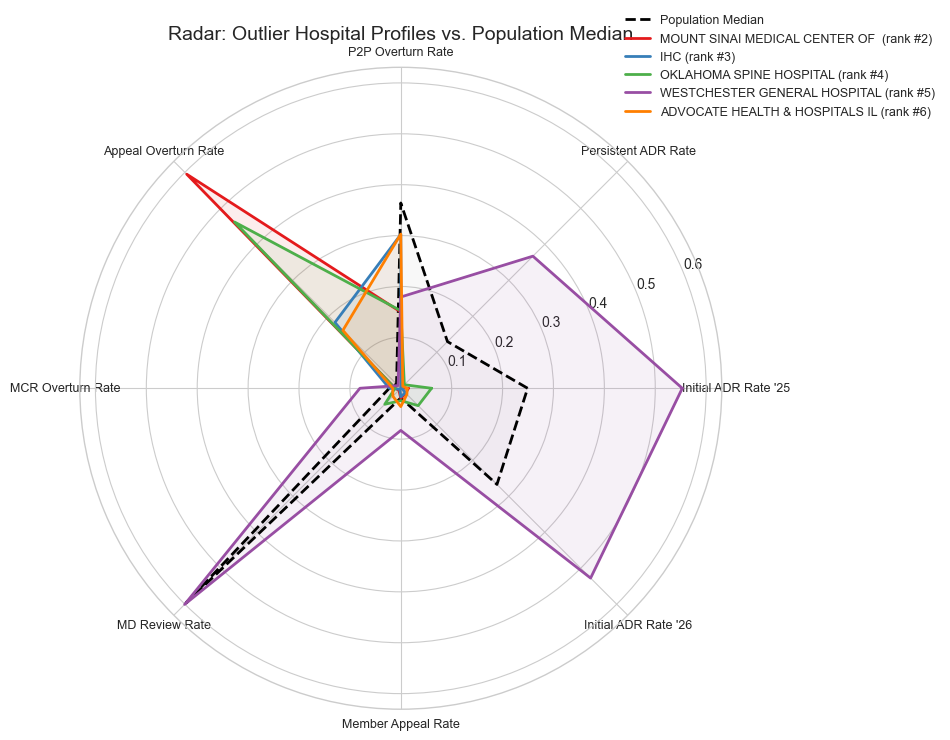

In [133]:
# =============================================================================
# VIZ 1: RADAR / SPIDER CHART
# Shows each hospital's profile overlaid on the population median
# =============================================================================

def radar_chart(df_anomalies, pop_medians, kpi_cols, labels):
    n_metrics = len(kpi_cols)
    angles = [n / float(n_metrics) * 2 * pi for n in range(n_metrics)]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize = (10, 10), subplot_kw = dict(polar = True))

    median_vals = [pop_medians[c] for c in kpi_cols] + [pop_medians[kpi_cols[0]]]
    ax.plot(angles, median_vals, "k--", linewidth = 2, label = "Population Median")
    ax.fill(angles, median_vals, alpha = 0.05, color = "gray")

    colors = plt.cm.Set1(range(len(df_anomalies)))
    for i, (_, row) in enumerate(df_anomalies.iterrows()):
        vals = [row[c] for c in kpi_cols] + [row[kpi_cols[0]]]
        hosp_name = str(row.get('hospital_group', 'Unknown'))[:30]
        rank_val = int(row['anomaly_rank']) if pd.notna(row.get('anomaly_rank')) else 0
        ax.plot(angles, vals, linewidth = 2, color = colors[i],
                label = f"{hosp_name} (rank #{rank_val})")
        ax.fill(angles, vals, alpha = 0.08, color = colors[i])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, size = 9)
    ax.set_title("Radar: Outlier Hospital Profiles vs. Population Median", size = 14, pad = 20)
    ax.legend(loc = "upper right", bbox_to_anchor = (1.35, 1.1), fontsize = 9)
    plt.tight_layout()
    plt.show()

radar_chart(top_anomalies, pop_med_values, viz_kpi, viz_labels)

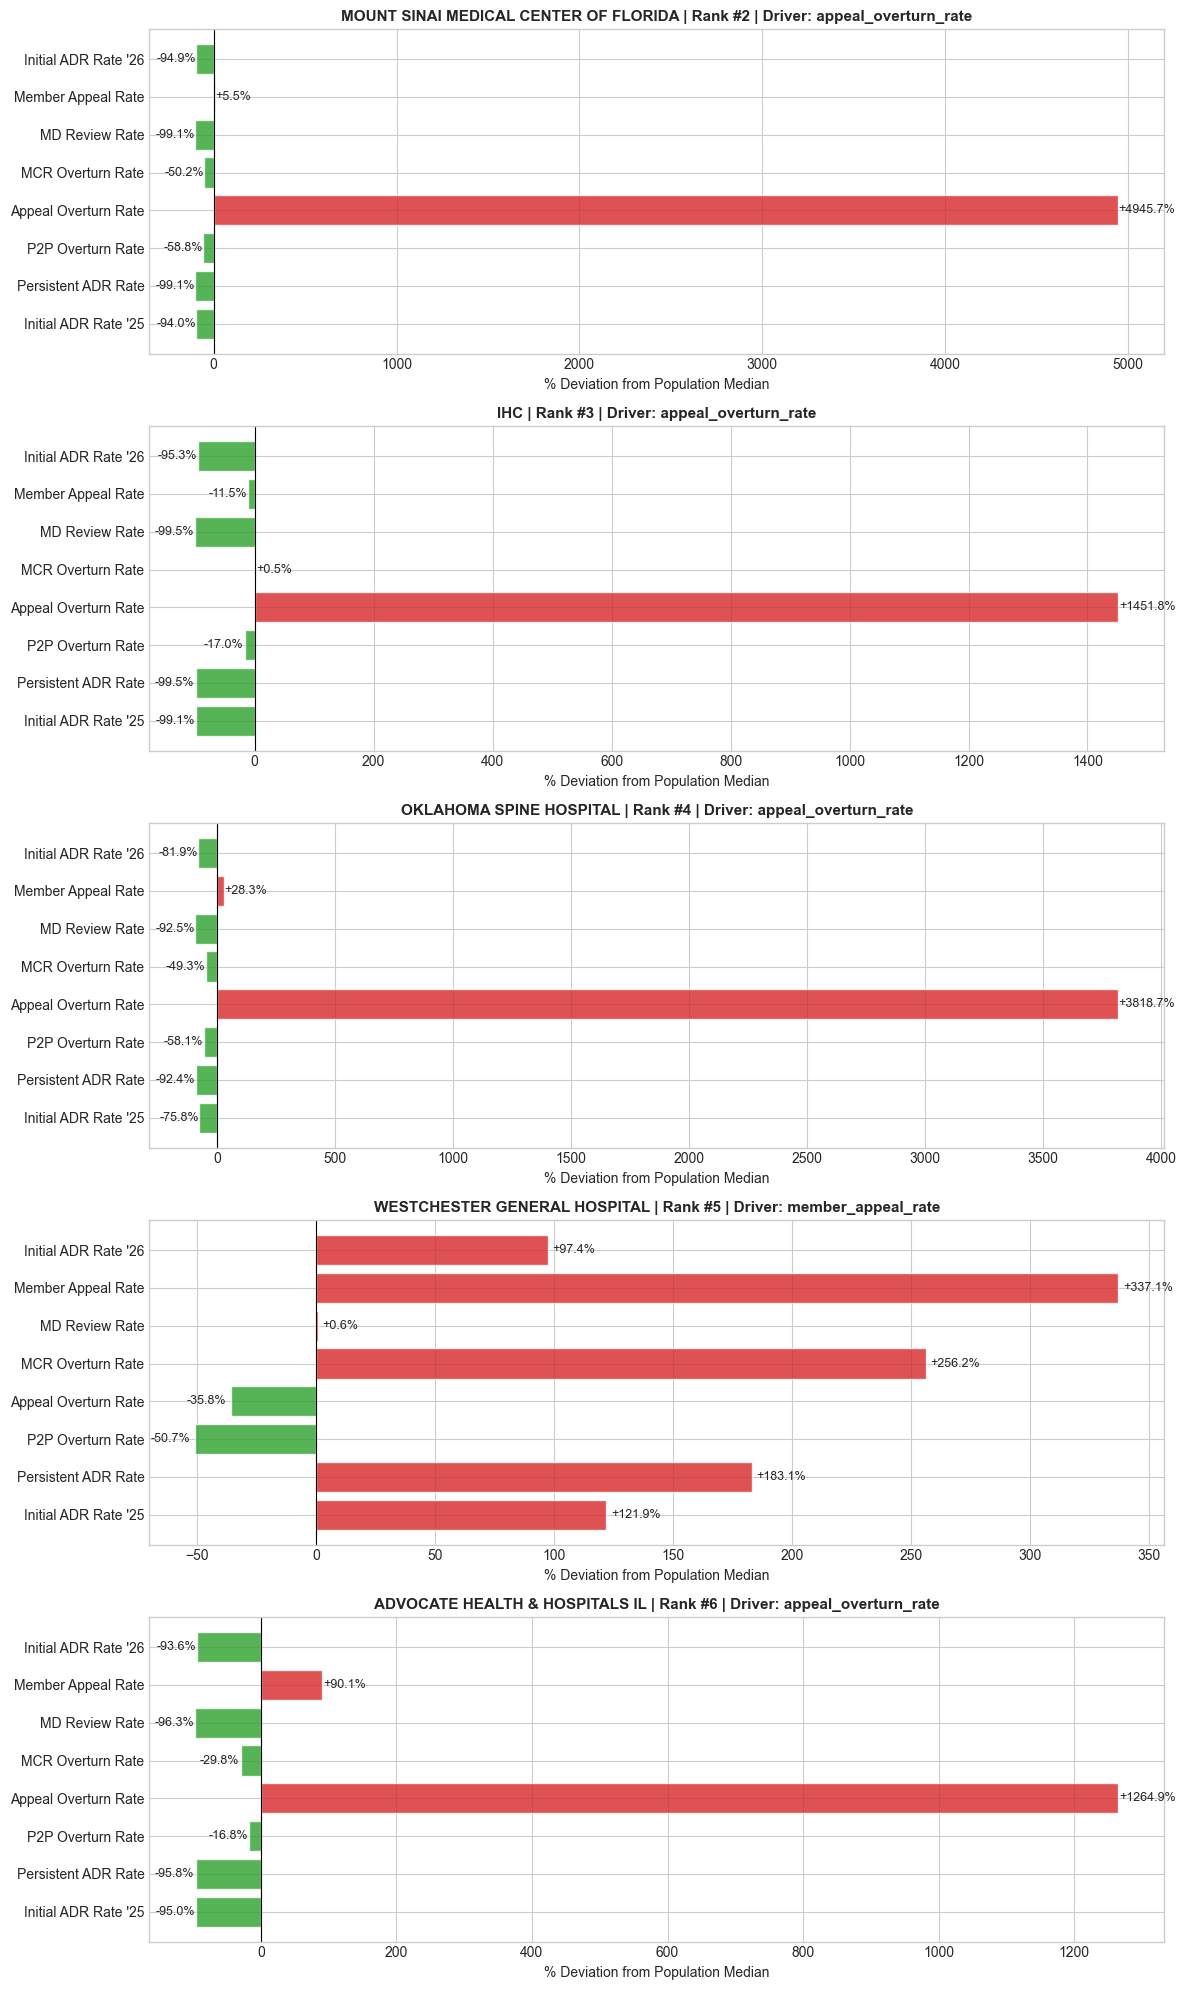

In [134]:
# =============================================================================
# VIZ 2: BAR CHART — % DEVIATION FROM MEDIAN
# One chart per hospital. Bars show how far each metric deviates from median.
# =============================================================================

def deviation_bar_chart(df_anomalies, pop_medians, kpi_cols, labels):
    n_hospitals = len(df_anomalies)
    fig, axes = plt.subplots(n_hospitals, 1, figsize = (12, 4 * n_hospitals))
    if n_hospitals == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, df_anomalies.iterrows()):
        devs = []
        for col in kpi_cols:
            med = pop_medians[col]
            devs.append((row[col] - med) / med * 100 if med != 0 else 0)

        colors = ["#d62728" if d > 0 else "#2ca02c" for d in devs]
        y_pos = range(len(labels))

        ax.barh(y_pos, devs, color = colors, alpha = 0.8, edgecolor = "white")
        ax.set_yticks(y_pos)
        ax.set_yticklabels(labels, fontsize = 10)
        ax.set_xlabel("% Deviation from Population Median", fontsize = 10)

        hosp_name = str(row.get('hospital_group', 'Unknown'))[:40]
        rank_val = int(row['anomaly_rank']) if pd.notna(row.get('anomaly_rank')) else 0
        driver_val = str(row.get('driver', 'N/A')) if pd.notna(row.get('driver')) else 'N/A'
        ax.set_title(
            f"{hosp_name} | Rank #{rank_val} | Driver: {driver_val}",
            fontsize = 11, fontweight = "bold"
        )
        ax.axvline(0, color = "black", linewidth = 0.8)

        for i, d in enumerate(devs):
            ax.text(d + (2 if d >= 0 else -2), i, f"{d:+.1f}%",
                    va = "center", ha = "left" if d >= 0 else "right", fontsize = 9)

    plt.tight_layout()
    plt.show()

deviation_bar_chart(top_anomalies, pop_med_values, viz_kpi, viz_labels)

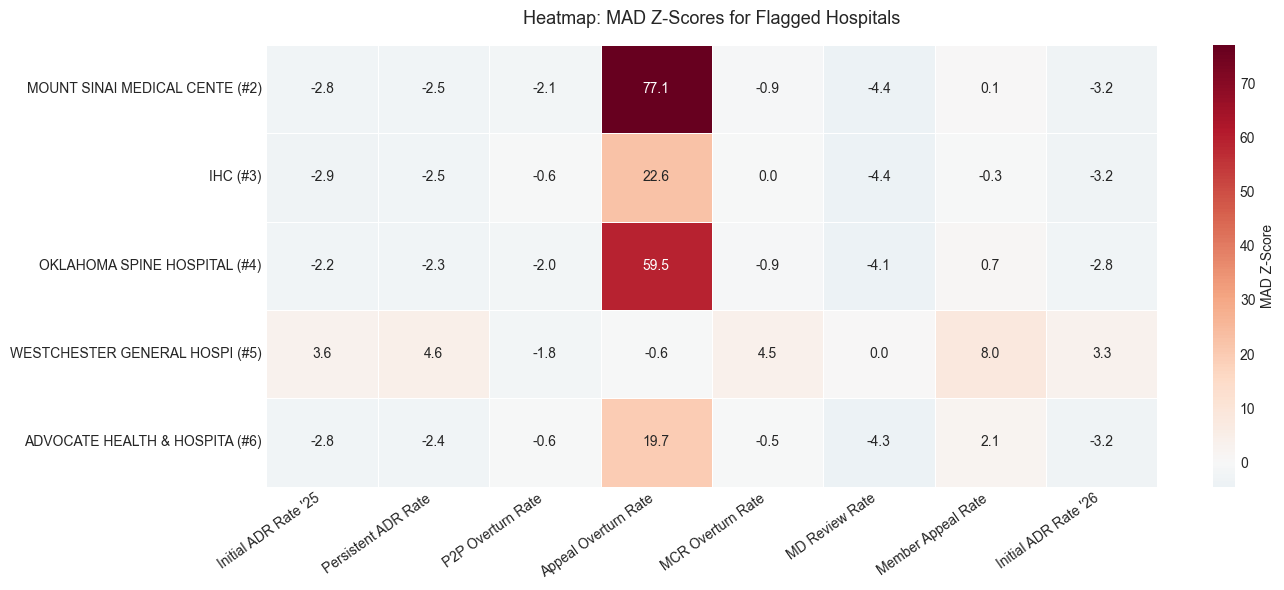

In [135]:
# =============================================================================
# VIZ 3: HEATMAP — MULTIPLE HOSPITALS AT ONCE
# Rows = hospitals, columns = metrics, color = MAD z-score intensity
# =============================================================================

import seaborn as sns

def anomaly_heatmap(df_anomalies, kpi_cols, labels):
    z_data = df_anomalies[[f"{c}_z" for c in kpi_cols]].copy()
    z_data.columns = labels
    z_data.index = [
        f"{str(row.get('hospital_group', 'Unknown'))[:25]} (#{int(row['anomaly_rank']) if pd.notna(row.get('anomaly_rank')) else 0})"
        for _, row in df_anomalies.iterrows()
    ]

    fig, ax = plt.subplots(figsize = (14, max(4, len(df_anomalies) * 0.8 + 2)))
    sns.heatmap(
        z_data, annot = True, fmt = ".1f", cmap = "RdBu_r", center = 0,
        linewidths = 0.5, ax = ax, cbar_kws = {"label": "MAD Z-Score"}
    )
    ax.set_title("Heatmap: MAD Z-Scores for Flagged Hospitals", fontsize = 13, pad = 15)
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.xticks(rotation = 35, ha = "right")
    plt.tight_layout()
    plt.show()

anomaly_heatmap(top_anomalies, viz_kpi, viz_labels)

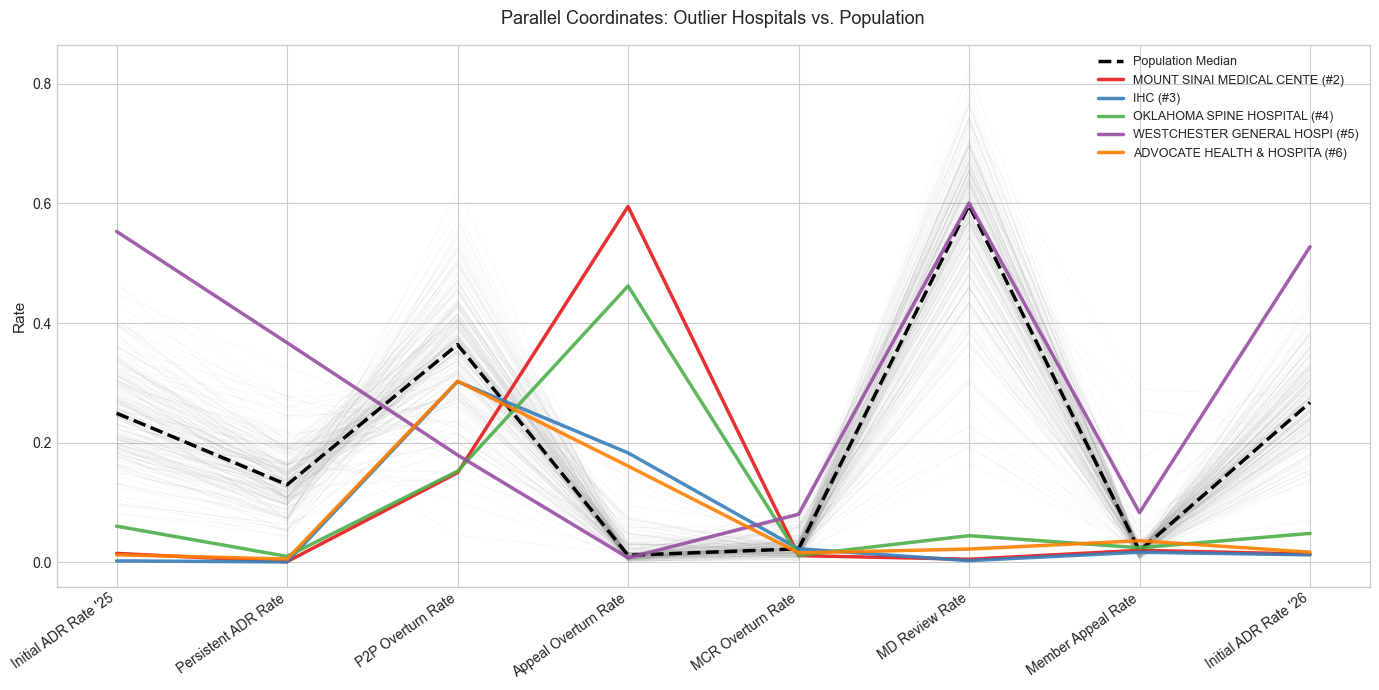

In [136]:
# =============================================================================
# VIZ 4: PARALLEL COORDINATES
# Each line = a hospital. Outliers visually diverge from the normal cluster.
# =============================================================================

def parallel_coordinates_plot(df_full, df_anomalies, kpi_cols, labels):
    fig, ax = plt.subplots(figsize = (14, 7))

    norm_data = df_full[~df_full["anomaly_flag"]][kpi_cols]
    for _, row in norm_data.sample(min(200, len(norm_data)), random_state = 42).iterrows():
        ax.plot(range(len(kpi_cols)), [row[c] for c in kpi_cols],
                color = "gray", alpha = 0.08, linewidth = 0.5)

    med_vals = [pop_med_values[c] for c in kpi_cols]
    ax.plot(range(len(kpi_cols)), med_vals, "k--", linewidth = 2.5, label = "Population Median")

    colors = plt.cm.Set1(range(len(df_anomalies)))
    for i, (_, row) in enumerate(df_anomalies.iterrows()):
        ax.plot(range(len(kpi_cols)), [row[c] for c in kpi_cols],
                color = colors[i], linewidth = 2.5, alpha = 0.9,
                label = f"{row['hospital_group'][:25]} (#{int(row['anomaly_rank'])})")

    ax.set_xticks(range(len(kpi_cols)))
    ax.set_xticklabels(labels, rotation = 35, ha = "right", fontsize = 10)
    ax.set_ylabel("Rate", fontsize = 11)
    ax.set_title("Parallel Coordinates: Outlier Hospitals vs. Population", fontsize = 13, pad = 15)
    ax.legend(loc = "upper right", fontsize = 9)
    plt.tight_layout()
    plt.show()

parallel_coordinates_plot(df_iso, top_anomalies, viz_kpi, viz_labels)

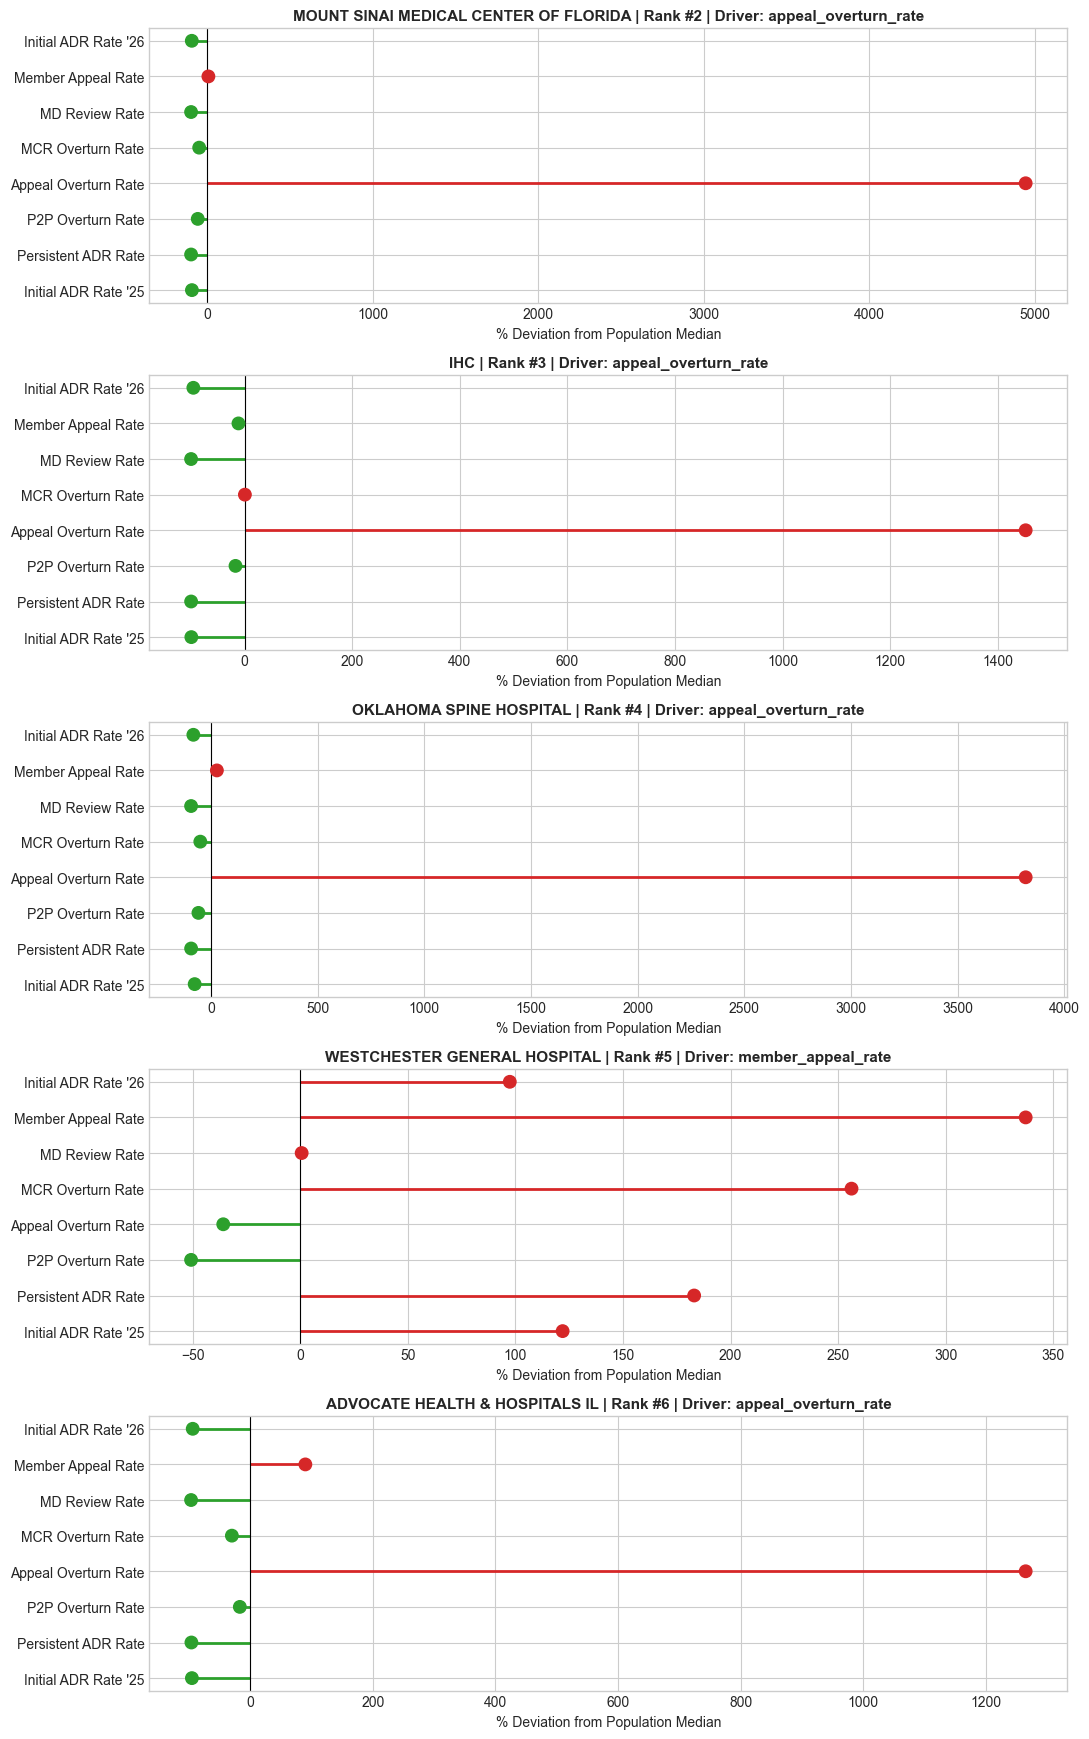

In [137]:
# =============================================================================
# VIZ 5: LOLLIPOP CHART — CLEAN ALTERNATIVE TO BAR CHART
# Shows each metric's deviation as a dot + stem from zero. Good for slides.
# =============================================================================

def lollipop_chart(df_anomalies, pop_medians, kpi_cols, labels):
    n_hospitals = len(df_anomalies)
    fig, axes = plt.subplots(n_hospitals, 1, figsize = (11, 3.5 * n_hospitals))
    if n_hospitals == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, df_anomalies.iterrows()):
        devs = []
        for col in kpi_cols:
            med = pop_medians[col]
            devs.append((row[col] - med) / med * 100 if med != 0 else 0)

        colors = ["#d62728" if d > 0 else "#2ca02c" for d in devs]
        y_pos = range(len(labels))

        ax.hlines(y_pos, 0, devs, color = colors, linewidth = 2)
        ax.scatter(devs, y_pos, color = colors, s = 80, zorder = 3)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(labels, fontsize = 10)
        ax.set_xlabel("% Deviation from Population Median", fontsize = 10)
        ax.axvline(0, color = "black", linewidth = 0.8)

        hosp_name = str(row.get('hospital_group', 'Unknown'))[:40]
        rank_val = int(row['anomaly_rank']) if pd.notna(row.get('anomaly_rank')) else 0
        driver_val = str(row.get('driver', 'N/A')) if pd.notna(row.get('driver')) else 'N/A'
        ax.set_title(
            f"{hosp_name} | Rank #{rank_val} | Driver: {driver_val}",
            fontsize = 11, fontweight = "bold"
        )

    plt.tight_layout()
    plt.show()

lollipop_chart(top_anomalies, pop_med_values, viz_kpi, viz_labels)

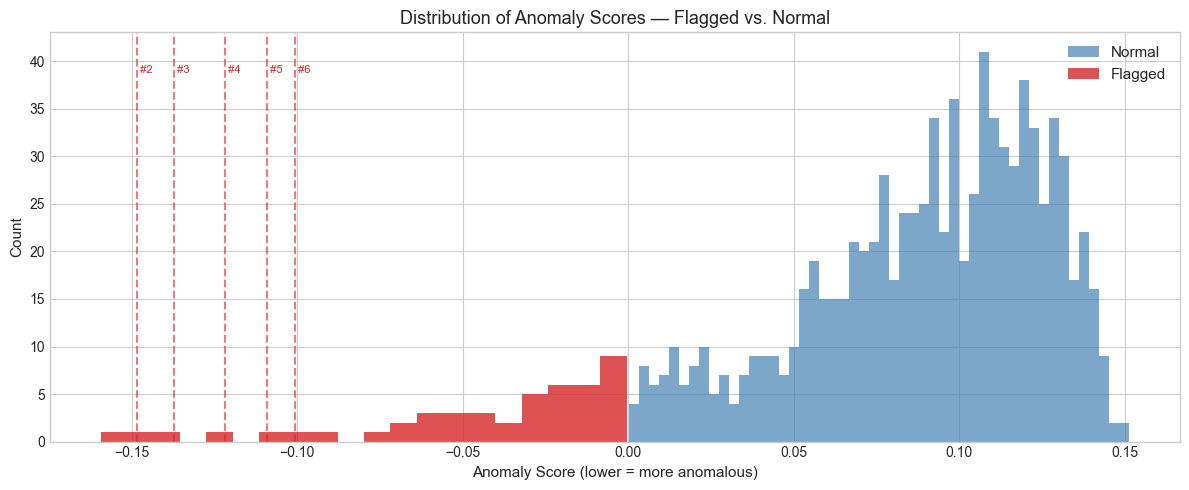

In [138]:
# =============================================================================
# VIZ 6: ANOMALY SCORE DISTRIBUTION + FLAGGED MARKERS
# Shows where flagged hospitals fall on the anomaly score spectrum
# =============================================================================

def score_distribution(df_full):
    fig, ax = plt.subplots(figsize = (12, 5))

    normal = df_full[~df_full["anomaly_flag"]]["anomaly_score"]
    flagged = df_full[df_full["anomaly_flag"]]["anomaly_score"]

    ax.hist(normal, bins = 50, alpha = 0.7, color = "steelblue", label = "Normal")
    ax.hist(flagged, bins = 20, alpha = 0.8, color = "#d62728", label = "Flagged")

    for _, row in top_anomalies.iterrows():
        ax.axvline(row["anomaly_score"], color = "#d62728", linestyle = "--", alpha = 0.6)
        ax.text(row["anomaly_score"], ax.get_ylim()[1] * 0.9,
                f" #{int(row['anomaly_rank'])}", fontsize = 8, color = "#d62728")

    ax.set_xlabel("Anomaly Score (lower = more anomalous)", fontsize = 11)
    ax.set_ylabel("Count", fontsize = 11)
    ax.set_title("Distribution of Anomaly Scores — Flagged vs. Normal", fontsize = 13)
    ax.legend(fontsize = 11)
    plt.tight_layout()
    plt.show()

score_distribution(df_iso)

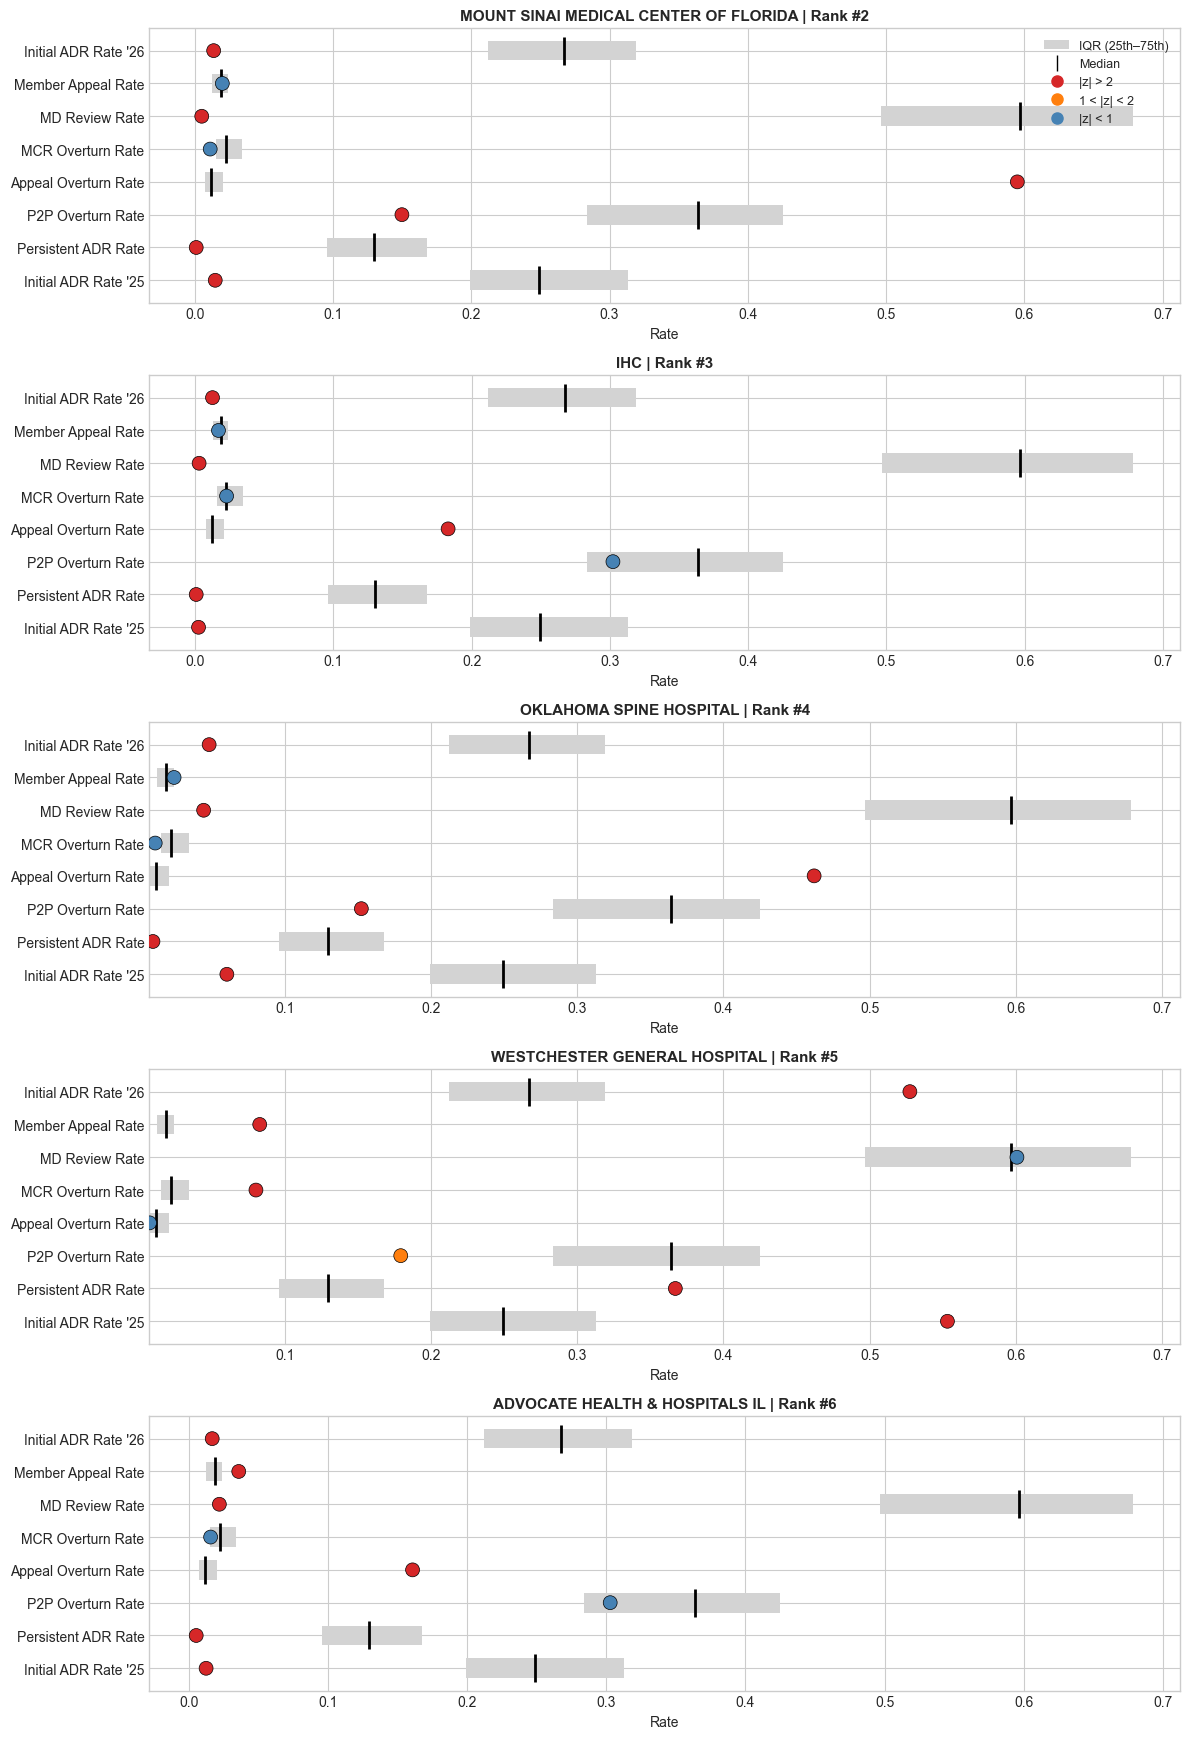

In [139]:
# =============================================================================
# VIZ 7: BULLET CHART — HOSPITAL VALUE VS POPULATION RANGE
# Shows entity value as a dot, median as a line, IQR as a band.
# Great for "how does this hospital compare to the spread?"
# =============================================================================

def bullet_chart(df_anomalies, df_full, kpi_cols, labels):
    n_hospitals = len(df_anomalies)
    fig, axes = plt.subplots(n_hospitals, 1, figsize = (12, 3.5 * n_hospitals))
    if n_hospitals == 1:
        axes = [axes]

    q25 = df_full[kpi_cols].quantile(0.25)
    q75 = df_full[kpi_cols].quantile(0.75)
    medians = df_full[kpi_cols].median()

    for ax, (_, row) in zip(axes, df_anomalies.iterrows()):
        y_pos = range(len(kpi_cols))

        for i, col in enumerate(kpi_cols):
            ax.barh(i, q75[col] - q25[col], left = q25[col],
                    color = "lightgray", edgecolor = "none", height = 0.6)
            ax.plot(medians[col], i, "|", color = "black", markersize = 20, markeredgewidth = 2)

        vals = [row[c] for c in kpi_cols]
        colors = ["#d62728" if abs(row[f"{c}_z"]) > 2 else "#ff7f0e" if abs(row[f"{c}_z"]) > 1 else "steelblue"
                  for c in kpi_cols]
        ax.scatter(vals, y_pos, color = colors, s = 100, zorder = 3, edgecolors = "black", linewidth = 0.5)

        ax.set_yticks(y_pos)
        ax.set_yticklabels(labels, fontsize = 10)
        ax.set_xlabel("Rate", fontsize = 10)

        hosp_name = str(row.get('hospital_group', 'Unknown'))[:40]
        rank_val = int(row['anomaly_rank']) if pd.notna(row.get('anomaly_rank')) else 0
        ax.set_title(
            f"{hosp_name} | Rank #{rank_val}",
            fontsize = 11, fontweight = "bold"
        )

    legend_elements = [
        mpatches.Patch(facecolor = "lightgray", label = "IQR (25th–75th)"),
        Line2D([0], [0], marker = "|", color = "black", label = "Median", markersize = 12, linewidth = 0),
        Line2D([0], [0], marker = "o", color = "#d62728", label = "|z| > 2", markersize = 8, linewidth = 0),
        Line2D([0], [0], marker = "o", color = "#ff7f0e", label = "1 < |z| < 2", markersize = 8, linewidth = 0),
        Line2D([0], [0], marker = "o", color = "steelblue", label = "|z| < 1", markersize = 8, linewidth = 0),
    ]
    axes[0].legend(handles = legend_elements, loc = "upper right", fontsize = 9)

    plt.tight_layout()
    plt.show()

bullet_chart(top_anomalies, df_iso, viz_kpi, viz_labels)